# Repeating Nuclear Transient Search Inline Notebook

This notebook is the current implementation surface for the repeating nuclear transient search. It keeps the workflow self-contained in executable cells, so every stage is visible, editable, and runnable without standalone nuclear modules or a CLI.

By default, running all cells fetches ASASSN-14ko from SkyPatrol, prepares the ASAS-SN light curve in flux-residual space, groups positive flare episodes, searches for a repeating recurrence period, writes run artifacts, and creates a MALCA review database for the candidate. Change `TARGET_ID` in the configuration cell to run sparse two-flare literature tests such as AT 2020vdq or AT 2022dbl.


## 1. Setup And Imports

The imports below deliberately use only low-level MALCA helpers where copying them would be bulky or counterproductive. The actual nuclear-search orchestration, target normalization, flare grouping, recurrence scoring, and review mapping are duplicated inline below.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable
import json
import math
import os
import shutil
import sqlite3
import sys
import time
import traceback

os.environ.setdefault('MPLCONFIGDIR', '/tmp/malca-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'malca').is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Low-level MALCA utilities reused by the inline notebook implementation.
# The notebook keeps the nuclear workflow logic inline in the cells below.
from malca.io.fetch import cone_search, download_lightcurve_by_id, download_lightcurve_by_gaia_id
from malca.core.utils import clean_lc, filter_bad_cameras, read_skypatrol_csv
from malca.io.table_io import read_parquet_table, write_parquet_table
from malca.review.store import db_connect, import_candidates

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
print(f'REPO_ROOT = {REPO_ROOT}')

/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO_ROOT = /Users/calder/code/malca


## 2. Configuration

These defaults run the real ASASSN-14ko fetch path. Set `TARGET_ID` to another built-in target in the next cell for sparse repeating-pTDE tests. Set `BACKEND = "skypatrol1"` if SkyPatrol2 is unavailable in your environment.


In [2]:
# Select one literature validation target at a time. Options are shown in the next cell.
TARGET_ID = 'asassn14ko'
RUN_DIR = REPO_ROOT / f'output/runs/nuclear/{TARGET_ID}_notebook'
BACKEND = 'skypatrol2'
CONE_RADIUS_ARCSEC = 10.0
REFRESH_CACHE = False
OVERWRITE_OUTPUTS = True

MIN_CLEAN_POINTS = 50
BASELINE_WINDOW_DAYS = 180.0
BASELINE_MIN_POINTS = 10
FLARE_SNR_THRESHOLD = 3.0
# ASAS-SN fallback light curves can catch only one point near each narrow flare peak.
MIN_FLARE_POINTS = 1
MIN_FLARE_PEAK_SNR = 3.0
MAX_FLARE_GAP_DAYS = 14.0
MAX_FLARE_DURATION_DAYS = 60.0
MERGE_BAND_GAP_DAYS = 7.0
PERIOD_MIN_DAYS = 30.0
PERIOD_MAX_DAYS = 1000.0
MIN_REPEATING_FLARES = 4
PERIOD_GRID_SIZE = 4000

RUN_VETTING = False
REVIEW_ALL = False
EXPECTED_ASASSN14KO_PERIOD_DAYS = 114.2

# These are populated from the selected target row in the target cell.
VALIDATION_MODE = 'many_cycle'
EXPECTED_PERIOD_DAYS = EXPECTED_ASASSN14KO_PERIOD_DAYS
EXPECTED_MIN_FLARES = 5
EXPECTED_PERIOD_TOLERANCE_DAYS = 10.0
EXPECTED_MIN_REPEATING_SCORE = 55.0

CONFIG = {
    'target_id': TARGET_ID,
    'run_dir': str(RUN_DIR),
    'backend': BACKEND,
    'cone_radius_arcsec': CONE_RADIUS_ARCSEC,
    'refresh_cache': REFRESH_CACHE,
    'overwrite_outputs': OVERWRITE_OUTPUTS,
    'min_clean_points': MIN_CLEAN_POINTS,
    'baseline_window_days': BASELINE_WINDOW_DAYS,
    'baseline_min_points': BASELINE_MIN_POINTS,
    'flare_snr_threshold': FLARE_SNR_THRESHOLD,
    'min_flare_points': MIN_FLARE_POINTS,
    'min_flare_peak_snr': MIN_FLARE_PEAK_SNR,
    'max_flare_gap_days': MAX_FLARE_GAP_DAYS,
    'max_flare_duration_days': MAX_FLARE_DURATION_DAYS,
    'merge_band_gap_days': MERGE_BAND_GAP_DAYS,
    'period_min_days': PERIOD_MIN_DAYS,
    'period_max_days': PERIOD_MAX_DAYS,
    'min_repeating_flares': MIN_REPEATING_FLARES,
    'period_grid_size': PERIOD_GRID_SIZE,
    'run_vetting': RUN_VETTING,
    'review_all': REVIEW_ALL,
    'validation_mode': VALIDATION_MODE,
    'expected_period_days': EXPECTED_PERIOD_DAYS,
    'expected_min_flares': EXPECTED_MIN_FLARES,
    'expected_period_tolerance_days': EXPECTED_PERIOD_TOLERANCE_DAYS,
    'expected_min_repeating_score': EXPECTED_MIN_REPEATING_SCORE,
}
CONFIG

{'target_id': 'asassn14ko',
 'run_dir': '/Users/calder/code/malca/output/runs/nuclear/asassn14ko_notebook',
 'backend': 'skypatrol2',
 'cone_radius_arcsec': 10.0,
 'refresh_cache': False,
 'overwrite_outputs': True,
 'min_clean_points': 50,
 'baseline_window_days': 180.0,
 'baseline_min_points': 10,
 'flare_snr_threshold': 3.0,
 'min_flare_points': 1,
 'min_flare_peak_snr': 3.0,
 'max_flare_gap_days': 14.0,
 'max_flare_duration_days': 60.0,
 'merge_band_gap_days': 7.0,
 'period_min_days': 30.0,
 'period_max_days': 1000.0,
 'min_repeating_flares': 4,
 'period_grid_size': 4000,
 'run_vetting': False,
 'review_all': False,
 'validation_mode': 'many_cycle',
 'expected_period_days': 114.2,
 'expected_min_flares': 5,
 'expected_period_tolerance_days': 10.0,
 'expected_min_repeating_score': 55.0}

## 3. Built-In Literature Validation Targets

The notebook runs one target at a time so the fetch, plots, flare table, recurrence score, and review ingest are easy to inspect. Set `TARGET_ID` in the configuration cell to switch between ASASSN-14ko and sparse two-flare literature tests.


In [3]:
BUILTIN_TARGETS = pd.DataFrame([
    {
        'target_id': 'asassn14ko',
        'name': 'ASASSN-14ko',
        'host_name': 'ESO 253-G003',
        'ra': 81.3255,
        'dec': -46.0057,
        'redshift': 0.042489,
        'expected_period_days': EXPECTED_ASASSN14KO_PERIOD_DAYS,
        'target_type': 'validation',
        'validation_mode': 'many_cycle',
        'expected_min_flares': 5,
        'period_tolerance_days': 10.0,
        'min_repeating_flares': 4,
        'min_repeating_score': 55.0,
        'period_max_days': 1000.0,
        'literature_note': 'ASAS-SN optical periodic nuclear transient; many-cycle validation target.',
    },
    {
        'target_id': 'at2020vdq',
        'name': 'AT 2020vdq',
        'host_name': '',
        'ra': 152.222667,
        'dec': 42.716731,
        'redshift': 0.044,
        'expected_period_days': 947.0,
        'target_type': 'literature_sparse_repeat',
        'validation_mode': 'two_flare',
        'expected_min_flares': 2,
        'period_tolerance_days': 180.0,
        'min_repeating_flares': 2,
        'min_repeating_score': 35.0,
        'period_max_days': 1200.0,
        'literature_note': 'ZTF20acaazkt / AT 2020vdq; optical pTDE rebrightening about 947 days after discovery.',
    },
    {
        'target_id': 'at2022dbl',
        'name': 'AT 2022dbl / ASASSN-22ci',
        'host_name': '',
        'ra': 185.18754,
        'dec': 49.55130,
        'redshift': 0.0284,
        'expected_period_days': 700.0,
        'target_type': 'literature_sparse_repeat',
        'validation_mode': 'two_flare',
        'expected_min_flares': 2,
        'period_tolerance_days': 140.0,
        'min_repeating_flares': 2,
        'min_repeating_score': 35.0,
        'period_max_days': 1000.0,
        'literature_note': 'Spectroscopically confirmed repeated pTDE; optical/UV flare repeated after roughly 700 days.',
    },
    {
        'target_id': 'at2018fyk',
        'name': 'AT 2018fyk / ASASSN-18ul',
        'host_name': '',
        'ra': 342.56708,
        'dec': -44.86486,
        'redshift': 0.059,
        'expected_period_days': 1200.0,
        'target_type': 'literature_long_period_repeat',
        'validation_mode': 'two_flare',
        'expected_min_flares': 2,
        'period_tolerance_days': 180.0,
        'min_repeating_flares': 2,
        'min_repeating_score': 35.0,
        'period_max_days': 1600.0,
        'literature_note': 'Proposed repeating partial TDE with rebrightening on an approximately 1200 day orbit.',
    },
])


def normalize_token(value: object) -> str:
    if value is None:
        return ''
    try:
        if pd.isna(value):
            return ''
    except Exception:
        pass
    text = str(value).strip()
    if text.lower() in {'', 'nan', 'none', '<na>'}:
        return ''
    return text


def slugify_token(value: object, *, fallback: str = 'target') -> str:
    text = normalize_token(value).lower()
    out = []
    prev_us = False
    for ch in text:
        keep = ch.isalnum()
        if keep:
            out.append(ch)
            prev_us = False
        elif not prev_us:
            out.append('_')
            prev_us = True
    token = ''.join(out).strip('_')
    return token or fallback


def normalize_target_table(df: pd.DataFrame) -> pd.DataFrame:
    required = {'ra', 'dec'}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'Target table missing required columns: {missing}')

    out = df.copy()
    if 'target_id' not in out.columns:
        source = out['name'] if 'name' in out.columns else pd.Series(range(len(out)), index=out.index)
        out['target_id'] = source.map(lambda value: slugify_token(value, fallback='target'))
    out['target_id'] = out['target_id'].map(lambda value: slugify_token(value, fallback='target'))
    out['name'] = out['name'].map(normalize_token) if 'name' in out.columns else out['target_id']
    out['host_name'] = out['host_name'].map(normalize_token) if 'host_name' in out.columns else ''
    out['target_type'] = out['target_type'].map(normalize_token) if 'target_type' in out.columns else ''
    out['validation_mode'] = out['validation_mode'].map(normalize_token) if 'validation_mode' in out.columns else 'many_cycle'
    out['literature_note'] = out['literature_note'].map(normalize_token) if 'literature_note' in out.columns else ''
    out['ra'] = pd.to_numeric(out['ra'], errors='coerce')
    out['dec'] = pd.to_numeric(out['dec'], errors='coerce')
    for col, default in (
        ('redshift', np.nan),
        ('expected_period_days', np.nan),
        ('expected_min_flares', 5),
        ('period_tolerance_days', 10.0),
        ('min_repeating_flares', 4),
        ('min_repeating_score', 55.0),
        ('period_max_days', PERIOD_MAX_DAYS),
    ):
        out[col] = pd.to_numeric(out[col] if col in out.columns else default, errors='coerce')
    bad = out['ra'].isna() | out['dec'].isna()
    if bool(bad.any()):
        raise ValueError(f'Target table has non-finite RA/Dec rows: {out.loc[bad, ["target_id", "ra", "dec"]].to_dict("records")}')
    out = out.drop_duplicates(subset=['target_id'], keep='first').reset_index(drop=True)
    out['candidate_id'] = out['target_id'].map(lambda value: f'nuclear_{value}')
    return out


all_validation_targets = normalize_target_table(BUILTIN_TARGETS)
if TARGET_ID not in set(all_validation_targets['target_id']):
    options = ', '.join(all_validation_targets['target_id'].tolist())
    raise ValueError(f'Unknown TARGET_ID={TARGET_ID!r}. Choose one of: {options}')

target_df = all_validation_targets.loc[all_validation_targets['target_id'] == TARGET_ID].reset_index(drop=True)
active_target = target_df.iloc[0].to_dict()

VALIDATION_MODE = active_target.get('validation_mode') or 'many_cycle'
EXPECTED_PERIOD_DAYS = float(active_target.get('expected_period_days'))
EXPECTED_MIN_FLARES = int(active_target.get('expected_min_flares') or 5)
EXPECTED_PERIOD_TOLERANCE_DAYS = float(active_target.get('period_tolerance_days') or 10.0)
EXPECTED_MIN_REPEATING_SCORE = float(active_target.get('min_repeating_score') or 55.0)
MIN_REPEATING_FLARES = int(active_target.get('min_repeating_flares') or MIN_REPEATING_FLARES)
PERIOD_MAX_DAYS = max(float(PERIOD_MAX_DAYS), float(active_target.get('period_max_days') or PERIOD_MAX_DAYS))
RUN_DIR = REPO_ROOT / f'output/runs/nuclear/{TARGET_ID}_notebook'
CONFIG.update({
    'target_id': TARGET_ID,
    'run_dir': str(RUN_DIR),
    'validation_mode': VALIDATION_MODE,
    'expected_period_days': EXPECTED_PERIOD_DAYS,
    'expected_min_flares': EXPECTED_MIN_FLARES,
    'expected_period_tolerance_days': EXPECTED_PERIOD_TOLERANCE_DAYS,
    'expected_min_repeating_score': EXPECTED_MIN_REPEATING_SCORE,
    'min_repeating_flares': MIN_REPEATING_FLARES,
    'period_max_days': PERIOD_MAX_DAYS,
    'literature_note': active_target.get('literature_note', ''),
})

print('Available validation targets:')
display(all_validation_targets[['target_id', 'name', 'validation_mode', 'expected_period_days', 'expected_min_flares', 'period_tolerance_days', 'literature_note']])
print(f'Selected TARGET_ID={TARGET_ID!r}; mode={VALIDATION_MODE!r}; run_dir={RUN_DIR.relative_to(REPO_ROOT)}')
display(target_df)


Available validation targets:


,target_id,name,validation_mode,expected_period_days,expected_min_flares,period_tolerance_days,literature_note
0,asassn14ko,ASASSN-14ko,many_cycle,114.2,5,10.0,ASAS-SN optical periodic nuclear transient; ma...
1,at2020vdq,AT 2020vdq,two_flare,947.0,2,180.0,ZTF20acaazkt / AT 2020vdq; optical pTDE rebrig...
2,at2022dbl,AT 2022dbl / ASASSN-22ci,two_flare,700.0,2,140.0,Spectroscopically confirmed repeated pTDE; opt...
3,at2018fyk,AT 2018fyk / ASASSN-18ul,two_flare,1200.0,2,180.0,Proposed repeating partial TDE with rebrighten...


Selected TARGET_ID='asassn14ko'; mode='many_cycle'; run_dir=output/runs/nuclear/asassn14ko_notebook


,target_id,name,host_name,ra,dec,redshift,expected_period_days,target_type,validation_mode,expected_min_flares,period_tolerance_days,min_repeating_flares,min_repeating_score,period_max_days,literature_note,candidate_id
0,asassn14ko,ASASSN-14ko,ESO 253-G003,81.3255,-46.0057,0.042489,114.2,validation,many_cycle,5,10.0,4,55.0,1000.0,ASAS-SN optical periodic nuclear transient; ma...,nuclear_asassn14ko


## 4. Path Helpers And Artifact Layout

This is an inline copy of the planned `malca/nuclear/paths.py` behavior, with run metadata writing copied from the style of `malca.products.run_context`.

In [4]:
def nuclear_results_dir(run_dir: str | Path | None = None) -> Path:
    return Path(run_dir or RUN_DIR).expanduser() / 'results'


def nuclear_review_dir(run_dir: str | Path | None = None) -> Path:
    return Path(run_dir or RUN_DIR).expanduser() / 'review'


def nuclear_review_db_path(run_dir: str | Path | None = None) -> Path:
    return nuclear_review_dir(run_dir) / 'review.db'


def nuclear_lightcurve_dir(run_dir: str | Path | None = None) -> Path:
    return Path(run_dir or RUN_DIR).expanduser() / 'bundle_assets' / 'lightcurves'


def nuclear_targets_path(run_dir: str | Path | None = None) -> Path:
    return nuclear_results_dir(run_dir) / 'nuclear_targets.parquet'


def nuclear_lightcurves_path(run_dir: str | Path | None = None) -> Path:
    return nuclear_results_dir(run_dir) / 'nuclear_lightcurves.parquet'


def nuclear_flares_path(run_dir: str | Path | None = None) -> Path:
    return nuclear_results_dir(run_dir) / 'nuclear_flares.parquet'


def nuclear_candidates_path(run_dir: str | Path | None = None) -> Path:
    return nuclear_results_dir(run_dir) / 'nuclear_candidates.parquet'



def make_nuclear_run_paths(run_dir: str | Path | None = None) -> dict[str, Path]:
    """Return the artifact layout produced by this inline notebook run."""
    rd = Path(run_dir or RUN_DIR).expanduser()
    return {
        'run_dir': rd,
        'run_params': rd / 'run_params.json',
        'run_summary': rd / 'run_summary.json',
        'run_log': rd / 'run.log',
        'results_dir': nuclear_results_dir(rd),
        'targets': nuclear_targets_path(rd),
        'lightcurves': nuclear_lightcurves_path(rd),
        'flares': nuclear_flares_path(rd),
        'candidates': nuclear_candidates_path(rd),
        'review_dir': nuclear_review_dir(rd),
        'review_db': nuclear_review_db_path(rd),
        'bundle_lightcurve_dir': nuclear_lightcurve_dir(rd),
        'asassn14ko_bundle_csv': nuclear_lightcurve_dir(rd) / 'nuclear_asassn14ko.csv',
    }


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, default=str), encoding='ascii')


def safe_reset_notebook_run_dir(run_dir: Path) -> None:
    """Remove only the intended notebook run directory under output/runs/nuclear."""
    root = (REPO_ROOT / 'output/runs/nuclear').resolve()
    resolved = run_dir.resolve()
    if root != resolved and root not in resolved.parents:
        raise ValueError(f'Refusing to reset a run directory outside {root}: {resolved}')
    if 'notebook' not in run_dir.name:
        print(f'OVERWRITE_OUTPUTS=True, but {run_dir.name!r} does not look like a notebook run; leaving existing files in place.')
        return
    if run_dir.exists():
        shutil.rmtree(run_dir)
        print(f'Reset run directory: {run_dir}')


def initialize_run_layout(run_dir: Path, config: dict[str, Any], targets: pd.DataFrame) -> None:
    if OVERWRITE_OUTPUTS:
        safe_reset_notebook_run_dir(run_dir)
    nuclear_results_dir(run_dir).mkdir(parents=True, exist_ok=True)
    nuclear_review_dir(run_dir).mkdir(parents=True, exist_ok=True)
    nuclear_lightcurve_dir(run_dir).mkdir(parents=True, exist_ok=True)
    write_json(run_dir / 'run_params.json', {
        'timestamp': pd.Timestamp.utcnow().isoformat(),
        'notebook': 'malca/nuclear/repeating_nuclear_transient_search_inline.ipynb',
        'config': config,
        'targets': targets.to_dict('records'),
    })
    (run_dir / 'run.log').write_text(
        '\n'.join([
            f'timestamp: {pd.Timestamp.utcnow().isoformat()}',
            'notebook: malca/nuclear/repeating_nuclear_transient_search_inline.ipynb',
            f'run_dir: {run_dir}',
            f'backend: {BACKEND}',
            f'cone_radius_arcsec: {CONE_RADIUS_ARCSEC}',
        ]) + '\n',
        encoding='ascii',
    )


initialize_run_layout(RUN_DIR, CONFIG, target_df)
write_parquet_table(target_df, nuclear_targets_path(RUN_DIR))
print('Artifact layout:')
for path in [
    RUN_DIR / 'run_params.json',
    RUN_DIR / 'run.log',
    nuclear_targets_path(RUN_DIR),
    nuclear_lightcurves_path(RUN_DIR),
    nuclear_flares_path(RUN_DIR),
    nuclear_candidates_path(RUN_DIR),
    nuclear_review_db_path(RUN_DIR),
    nuclear_lightcurve_dir(RUN_DIR) / 'nuclear_asassn14ko.csv',
]:
    print(' ', path.relative_to(REPO_ROOT))

Reset run directory: /Users/calder/code/malca/output/runs/nuclear/asassn14ko_notebook
Artifact layout:
  output/runs/nuclear/asassn14ko_notebook/run_params.json
  output/runs/nuclear/asassn14ko_notebook/run.log
  output/runs/nuclear/asassn14ko_notebook/results/nuclear_targets.parquet
  output/runs/nuclear/asassn14ko_notebook/results/nuclear_lightcurves.parquet
  output/runs/nuclear/asassn14ko_notebook/results/nuclear_flares.parquet
  output/runs/nuclear/asassn14ko_notebook/results/nuclear_candidates.parquet
  output/runs/nuclear/asassn14ko_notebook/review/review.db
  output/runs/nuclear/asassn14ko_notebook/bundle_assets/lightcurves/nuclear_asassn14ko.csv


## 5. Coordinate Resolution And Fetch

This inline fetch path cone-searches at the galaxy nucleus, chooses the nearest SkyPatrol source, downloads by ASAS-SN ID, and copies the cached CSV into the run bundle.


In [5]:
def angular_separation_arcsec(ra1_deg: float, dec1_deg: float, ra2_deg: float, dec2_deg: float) -> float:
    ra1 = math.radians(float(ra1_deg) % 360.0)
    ra2 = math.radians(float(ra2_deg) % 360.0)
    dec1 = math.radians(float(dec1_deg))
    dec2 = math.radians(float(dec2_deg))
    dra = ((ra2 - ra1 + math.pi) % (2.0 * math.pi)) - math.pi
    s = math.sin((dec2 - dec1) / 2.0) ** 2 + math.cos(dec1) * math.cos(dec2) * math.sin(dra / 2.0) ** 2
    return math.degrees(2.0 * math.asin(math.sqrt(min(1.0, max(0.0, s))))) * 3600.0


def numeric_or_nan(value: object) -> float:
    try:
        out = float(value)
    except Exception:
        return float('nan')
    return out if math.isfinite(out) else float('nan')


def first_present(row: dict[str, Any], keys: Iterable[str], default: Any = None) -> Any:
    for key in keys:
        if key not in row:
            continue
        value = row[key]
        try:
            if pd.isna(value):
                continue
        except Exception:
            pass
        if str(value).strip() == '':
            continue
        return value
    return default


def choose_nearest_cone_match(target: dict[str, Any], matches: pd.DataFrame) -> tuple[dict[str, Any] | None, pd.DataFrame]:
    if matches is None or matches.empty:
        return None, pd.DataFrame()
    rows = []
    for _, raw in matches.iterrows():
        row = raw.to_dict()
        match_ra = numeric_or_nan(first_present(row, ('ra_deg', 'ra', 'raj2000')))
        match_dec = numeric_or_nan(first_present(row, ('dec_deg', 'dec', 'dej2000')))
        if not math.isfinite(match_ra) or not math.isfinite(match_dec):
            continue
        sep = angular_separation_arcsec(float(target['ra']), float(target['dec']), match_ra, match_dec)
        row['nuc_cone_sep_arcsec'] = sep
        row['_has_asas_sn_id'] = int(normalize_token(first_present(row, ('asas_sn_id',))) != '')
        rows.append(row)
    scored = pd.DataFrame(rows)
    if scored.empty:
        return None, scored
    scored = scored.sort_values(['_has_asas_sn_id', 'nuc_cone_sep_arcsec'], ascending=[False, True]).reset_index(drop=True)
    return scored.iloc[0].to_dict(), scored


def copy_lightcurve_to_run_bundle(source_path: Path, candidate_id: str, run_dir: Path) -> Path:
    out_dir = nuclear_lightcurve_dir(run_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    dst = out_dir / f'{candidate_id}.csv'
    if source_path.resolve() != dst.resolve():
        shutil.copy2(source_path, dst)
    meta_src = source_path.with_suffix(source_path.suffix + '.meta.json')
    if meta_src.exists():
        shutil.copy2(meta_src, dst.with_suffix(dst.suffix + '.meta.json'))
    return dst



def backend_fallback_order(primary_backend: str) -> list[str]:
    primary = str(primary_backend or 'skypatrol2').strip().lower()
    aliases = {'sp2': 'skypatrol2', 'sky-patrol2': 'skypatrol2', 'sp1': 'skypatrol1', 'sky-patrol1': 'skypatrol1'}
    primary = aliases.get(primary, primary)
    order = [primary]
    for candidate in ('skypatrol2', 'skypatrol1'):
        if candidate not in order:
            order.append(candidate)
    return order


def download_lightcurve_with_fallbacks(
    *,
    asas_sn_id: str,
    gaia_id: str,
    backend: str,
    refresh_cache: bool,
) -> tuple[Path, dict[str, Any], list[dict[str, str]], str, str, str]:
    """Try ASAS-SN and Gaia identifiers across SkyPatrol backends before failing."""
    identifiers: list[tuple[str, str, Any]] = []
    if normalize_token(asas_sn_id):
        identifiers.append(('asas_sn_id', normalize_token(asas_sn_id), download_lightcurve_by_id))
    if normalize_token(gaia_id):
        identifiers.append(('gaia_id', normalize_token(gaia_id), download_lightcurve_by_gaia_id))
    if not identifiers:
        raise RuntimeError('Nearest match has neither ASAS-SN ID nor Gaia ID')

    attempts: list[dict[str, str]] = []
    for backend_name in backend_fallback_order(backend):
        for id_kind, identifier, downloader in identifiers:
            attempt = {'backend': backend_name, 'id_kind': id_kind, 'id_value': identifier, 'status': 'attempted'}
            try:
                lc_path, catalog_info = downloader(identifier, backend=backend_name, refresh_cache=refresh_cache)
                attempt['status'] = 'fetched'
                attempts.append(attempt)
                return Path(lc_path), dict(catalog_info or {}), attempts, backend_name, id_kind, identifier
            except Exception as exc:
                attempt['status'] = 'failed'
                attempt['error'] = f'{type(exc).__name__}: {exc}'
                attempts.append(attempt)

    compact = '; '.join(f"{a['backend']} {a['id_kind']}={a['id_value']} -> {a.get('error', a['status'])}" for a in attempts)
    raise RuntimeError(f'No light curve returned by fallback attempts: {compact}')


def fetch_one_target(target: dict[str, Any], *, run_dir: Path, backend: str, radius_arcsec: float, refresh_cache: bool) -> tuple[dict[str, Any], pd.DataFrame, dict[str, Any] | None]:
    candidate_id = str(target['candidate_id'])
    base = {
        'candidate_id': candidate_id,
        'target_id': target['target_id'],
        'name': target.get('name', ''),
        'host_name': target.get('host_name', ''),
        'redshift': target.get('redshift', np.nan),
        'target_ra': float(target['ra']),
        'target_dec': float(target['dec']),
        'expected_period_days': target.get('expected_period_days', np.nan),
        'nuc_fetch_backend': backend,
        'nuc_fetch_status': 'error',
        'nuc_fetch_error': '',
        'lc_path': '',
    }

    all_matches = []
    chosen = None
    try:
        for catalog in ('master_list', 'stellar_main'):
            try:
                matches = cone_search(float(target['ra']), float(target['dec']), radius_arcsec=radius_arcsec, catalog=catalog, backend=backend)
                if matches is not None and not matches.empty:
                    matches = matches.copy()
                    matches['nuc_catalog'] = catalog
                    all_matches.append(matches)
                    chosen, scored = choose_nearest_cone_match(target, pd.concat(all_matches, ignore_index=True))
                    # Keep gathering catalogs. Some master_list ASAS-SN IDs resolve in the catalog
                    # but return no photometry from the SkyPatrol2 light-curve endpoint.
            except Exception as exc:
                print(f'Cone search failed for {candidate_id} in {catalog}: {exc}')
        scored_matches = pd.concat(all_matches, ignore_index=True) if all_matches else pd.DataFrame()
        if chosen is None:
            base.update({'nuc_fetch_status': 'no_match', 'nuc_fetch_error': 'No SkyPatrol cone-search match'})
            return base, scored_matches, None

        asas_sn_id = normalize_token(chosen.get('asas_sn_id'))
        gaia_id = normalize_token(chosen.get('gaia_id'))
        base.update({
            'asas_sn_id': asas_sn_id,
            'gaia_id': gaia_id,
            'match_ra': numeric_or_nan(first_present(chosen, ('ra_deg', 'ra', 'raj2000'))),
            'match_dec': numeric_or_nan(first_present(chosen, ('dec_deg', 'dec', 'dej2000'))),
            'nuc_cone_sep_arcsec': float(chosen.get('nuc_cone_sep_arcsec', np.nan)),
            'nuc_cone_n_matches': int(len(scored_matches)),
        })
        for key in ('parallax', 'plx', 'parallax_error', 'plx_d', 'pmra', 'pm_ra', 'pmdec', 'pm_dec', 'gaia_mag'):
            if key in chosen and normalize_token(chosen.get(key)):
                base[key] = chosen.get(key)

        if not asas_sn_id and not gaia_id:
            base.update({'nuc_fetch_status': 'no_match', 'nuc_fetch_error': 'Nearest match has neither ASAS-SN ID nor Gaia ID'})
            return base, scored_matches, chosen

        lc_path, catalog_info, download_attempts, used_backend, used_id_kind, used_id = download_lightcurve_with_fallbacks(
            asas_sn_id=asas_sn_id,
            gaia_id=gaia_id,
            backend=backend,
            refresh_cache=refresh_cache,
        )
        base.update({
            'nuc_fetch_attempts_json': json.dumps(download_attempts, default=str),
            'nuc_fetch_backend_used': used_backend,
            'nuc_fetch_id_kind_used': used_id_kind,
            'nuc_fetch_id_used': used_id,
        })

        bundled = copy_lightcurve_to_run_bundle(Path(lc_path), candidate_id, run_dir)
        if catalog_info:
            for key, value in catalog_info.items():
                if key not in base and normalize_token(value):
                    base[key] = value
        base.update({'nuc_fetch_status': 'fetched', 'lc_path': str(bundled)})
        return base, scored_matches, chosen
    except Exception as exc:
        base.update({'nuc_fetch_status': 'error', 'nuc_fetch_error': f'{type(exc).__name__}: {exc}'})
        traceback.print_exc()
        return base, pd.concat(all_matches, ignore_index=True) if all_matches else pd.DataFrame(), chosen



def fetch_one_target_lightcurve(target: dict[str, Any], *, run_dir: Path, backend: str, radius_arcsec: float, refresh_cache: bool) -> tuple[dict[str, Any], pd.DataFrame, dict[str, Any] | None]:
    """Wrapper around the inline cone-search/download orchestration."""
    return fetch_one_target(
        target,
        run_dir=run_dir,
        backend=backend,
        radius_arcsec=radius_arcsec,
        refresh_cache=refresh_cache,
    )


fetch_rows = []
cone_match_tables: dict[str, pd.DataFrame] = {}
chosen_matches: dict[str, dict[str, Any] | None] = {}
for target in tqdm(target_df.to_dict('records'), desc='Fetching nuclear targets'):
    manifest_row, matches, chosen = fetch_one_target_lightcurve(
        target,
        run_dir=RUN_DIR,
        backend=BACKEND,
        radius_arcsec=CONE_RADIUS_ARCSEC,
        refresh_cache=REFRESH_CACHE,
    )
    fetch_rows.append(manifest_row)
    cone_match_tables[str(target['target_id'])] = matches
    chosen_matches[str(target['target_id'])] = chosen

lightcurve_manifest = pd.DataFrame(fetch_rows)
write_parquet_table(lightcurve_manifest, nuclear_lightcurves_path(RUN_DIR))

target_id = target_df.loc[0, 'target_id']
print('Cone-search matches:')
display(cone_match_tables[target_id].head(10))
print('Chosen match:')
display(pd.DataFrame([chosen_matches[target_id] or {}]))
print('Light-curve manifest:')
display(lightcurve_manifest)

if lightcurve_manifest.loc[0, 'nuc_fetch_status'] == 'fetched':
    raw_preview = pd.read_csv(lightcurve_manifest.loc[0, 'lc_path']).head()
    display(raw_preview)

Fetching nuclear targets: 100%|██████████| 1/1 [00:03<00:00,  3.65s/it]

Cone-search matches:


,asas_sn_id,ra_deg,dec_deg,catalog_sources,nuc_catalog,refcat_id,gaia_id,hip_id,tyc_id,tmass_id,sdss_id,allwise_id,tic_id,plx,plx_d,pm_ra,pm_ra_d,pm_dec,pm_dec_d,gaia_mag,gaia_mag_d,gaia_b_mag,gaia_b_mag_d,gaia_r_mag,gaia_r_mag_d,gaia_eff_temp,gaia_g_extinc,gaia_var,sfd_g_extinc,rp_00_1,rp_01,rp_10,pstarrs_g_mag,pstarrs_g_mag_d,pstarrs_g_mag_chi,pstarrs_g_mag_contrib,pstarrs_r_mag,pstarrs_r_mag_d,pstarrs_r_mag_chi,pstarrs_r_mag_contrib,pstarrs_i_mag,pstarrs_i_mag_d,pstarrs_i_mag_chi,pstarrs_i_mag_contrib,pstarrs_z_mag,pstarrs_z_mag_d,pstarrs_z_mag_chi,pstarrs_z_mag_contrib,nstat
0,661431833080,81.322258,-46.005297,[swift],master_list,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,498216284073,81.325528,-46.005605,"[stellar_main, tic, milliquas, aavsovsx, allwi...",master_list,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,498216284073,81.325528,-46.005605,NaN,stellar_main,5.279081e+16,4.799083e+18,None,None,None,None,None,734783930.0,-0.8,0.14,-0.05,0.33,-1.85,0.31,16.43,0.006,16.033001,0.029,15.238,0.018,5095.0,0.0,2.0,0.136,33.700001,99.900002,99.900002,15.193,0.019,3.03,112.0,14.73,0.028,9.05,112.0,14.489,0.028,8.61,112.0,15.418,0.092,10.29,1.0,3.0


Chosen match:


,asas_sn_id,ra_deg,dec_deg,catalog_sources,nuc_catalog,refcat_id,gaia_id,hip_id,tyc_id,tmass_id,sdss_id,allwise_id,tic_id,plx,plx_d,pm_ra,pm_ra_d,pm_dec,pm_dec_d,gaia_mag,gaia_mag_d,gaia_b_mag,gaia_b_mag_d,gaia_r_mag,gaia_r_mag_d,gaia_eff_temp,gaia_g_extinc,gaia_var,sfd_g_extinc,rp_00_1,rp_01,rp_10,pstarrs_g_mag,pstarrs_g_mag_d,pstarrs_g_mag_chi,pstarrs_g_mag_contrib,pstarrs_r_mag,pstarrs_r_mag_d,pstarrs_r_mag_chi,pstarrs_r_mag_contrib,pstarrs_i_mag,pstarrs_i_mag_d,pstarrs_i_mag_chi,pstarrs_i_mag_contrib,pstarrs_z_mag,pstarrs_z_mag_d,pstarrs_z_mag_chi,pstarrs_z_mag_contrib,nstat,nuc_cone_sep_arcsec,_has_asas_sn_id
0,498216284073,81.325528,-46.005605,"[stellar_main, tic, milliquas, aavsovsx, allwi...",master_list,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.348499,1


Light-curve manifest:


,candidate_id,target_id,name,host_name,redshift,target_ra,target_dec,expected_period_days,nuc_fetch_backend,nuc_fetch_status,nuc_fetch_error,lc_path,asas_sn_id,gaia_id,match_ra,match_dec,nuc_cone_sep_arcsec,nuc_cone_n_matches,nuc_fetch_attempts_json,nuc_fetch_backend_used,nuc_fetch_id_kind_used,nuc_fetch_id_used,dec_deg,epochs,gaia_b_mag,gaia_b_mag_d,gaia_eff_temp,gaia_g_extinc,gaia_mag,gaia_mag_d,gaia_r_mag,gaia_r_mag_d,gaia_var,mean_vmag,nstat,plx,plx_d,pm_dec,pm_dec_d,pm_ra,pm_ra_d,pstarrs_g_mag,pstarrs_g_mag_chi,pstarrs_g_mag_contrib,pstarrs_g_mag_d,pstarrs_i_mag,pstarrs_i_mag_chi,pstarrs_i_mag_contrib,pstarrs_i_mag_d,pstarrs_r_mag,pstarrs_r_mag_chi,pstarrs_r_mag_contrib,pstarrs_r_mag_d,pstarrs_z_mag,pstarrs_z_mag_chi,pstarrs_z_mag_contrib,pstarrs_z_mag_d,ra_deg,refcat_id,rp_00_1,rp_01,rp_10,sfd_g_extinc,source_id,sp1_link,sp1_sep_arcsec,sp1_source_catalog,sp1_source_id,tic_id
0,nuclear_asassn14ko,asassn14ko,ASASSN-14ko,ESO 253-G003,0.042489,81.3255,-46.0057,114.2,skypatrol2,fetched,,/Users/calder/code/malca/output/runs/nuclear/a...,498216284073,,81.325528,-46.005605,0.348499,3,"[{""backend"": ""skypatrol2"", ""id_kind"": ""asas_sn...",skypatrol2,asas_sn_id,498216284073,-46.00566,301,16.033001,0.029,5095,0.0,16.43,0.006,15.238,0.018,2,14.7,3,-0.8,0.14,-1.85,0.31,-0.05,0.33,15.193,3.03,112,0.019,14.489,8.61,112,0.028,14.73,9.05,112,0.028,15.418,10.29,1,0.092,81.3254,52790813255273484,33.700001,99.900002,99.900002,0.136,4262829f-7832-5009-9bd9-5f44d0b40491,https://asas-sn.osu.edu/photometry/4262829f-78...,0.375929,DR9,4262829f-7832-5009-9bd9-5f44d0b40491,734783930


,JD,Flux,Flux Error,Mag,Mag Error,Limit,FWHM,Filter,Quality,Camera
0,2.456790e+06,4.978,0.154,14.717,0.03361,NaN,NaN,V,G,bf
1,2.456793e+06,5.046,0.155,14.702,0.03331,NaN,NaN,V,G,bf
2,2.456795e+06,5.345,0.158,14.640,0.03211,NaN,NaN,V,G,bf
3,2.456796e+06,5.167,0.156,14.677,0.03281,NaN,NaN,V,G,bf
4,2.456805e+06,4.726,0.151,14.773,0.03478,NaN,NaN,V,G,bf


## 6. Photometry Preparation

The search is done in flux-residual space. Brightening events are positive residuals, and this cell keeps the photometry preparation logic inline.


In [6]:
def finite_median(values: np.ndarray, default: float = np.nan) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.median(arr)) if arr.size else float(default)


def centered_rolling_median(x: np.ndarray, y: np.ndarray, *, window_days: float, min_points: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    baseline = np.full(y.shape, np.nan, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    global_median = finite_median(y[finite])
    if not np.isfinite(global_median):
        return baseline
    half_window = float(window_days) / 2.0
    for i, x_i in enumerate(x):
        if not np.isfinite(x_i):
            baseline[i] = global_median
            continue
        mask = finite & (np.abs(x - x_i) <= half_window)
        if int(mask.sum()) >= int(min_points):
            baseline[i] = finite_median(y[mask], default=global_median)
        else:
            baseline[i] = global_median
    return baseline



def estimate_band_baselines(jd: np.ndarray, values: np.ndarray, *, window_days: float = BASELINE_WINDOW_DAYS, min_points: int = BASELINE_MIN_POINTS) -> np.ndarray:
    """Estimate the smooth per-band baseline used for flux residuals."""
    return centered_rolling_median(jd, values, window_days=window_days, min_points=min_points)


def normalize_band_label(value: object) -> str:
    text = str(value or '').strip()
    if text.lower() == 'v':
        return 'V'
    if text.lower() == 'g':
        return 'g'
    return text or 'unknown'


def prepare_nuclear_lightcurve(
    lc_path: str | Path,
    *,
    min_clean_points: int = MIN_CLEAN_POINTS,
    baseline_window_days: float = BASELINE_WINDOW_DAYS,
    baseline_min_points: int = BASELINE_MIN_POINTS,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    raw = read_skypatrol_csv(lc_path)
    raw_n = len(raw)
    if raw.empty:
        return pd.DataFrame(), {'nuc_n_points_raw': 0, 'nuc_n_points_clean': 0, 'nuc_clean_status': 'empty'}

    work = raw.copy()
    work = clean_lc(work)
    if not work.empty:
        work, bad_cameras = filter_bad_cameras(
            work,
            lc_path=str(lc_path),
            filter_scatter=False,
            filter_offset=False,
            filter_catastrophic=True,
            cam_col='camera#',
            t_col='JD',
            mag_col='mag',
        )
    else:
        bad_cameras = set()

    summary: dict[str, Any] = {
        'nuc_n_points_raw': int(raw_n),
        'nuc_n_points_clean': int(len(work)),
        'nuc_bad_cameras_filtered': ','.join(str(cam) for cam in sorted(bad_cameras, key=str)),
        'nuc_clean_status': 'ok' if len(work) >= min_clean_points else 'too_few_points',
    }
    if work.empty:
        return pd.DataFrame(), summary

    work = work.sort_values('JD').reset_index(drop=True)
    if 'filter_band' in work.columns:
        work['band'] = work['filter_band'].map(normalize_band_label)
    elif 'v_g_band' in work.columns:
        work['band'] = np.where(pd.to_numeric(work['v_g_band'], errors='coerce') == 1, 'V', 'g')
    else:
        work['band'] = 'unknown'

    prepared_parts = []
    for band, band_df in work.groupby('band', sort=True):
        band_df = band_df.sort_values('JD').copy().reset_index(drop=True)
        jd = pd.to_numeric(band_df['JD'], errors='coerce').to_numpy(dtype=float)
        mag = pd.to_numeric(band_df['mag'], errors='coerce').to_numpy(dtype=float)
        mag_err = pd.to_numeric(band_df['error'], errors='coerce').to_numpy(dtype=float)
        flux = pd.to_numeric(band_df.get('flux', np.nan), errors='coerce').to_numpy(dtype=float)
        flux_err = pd.to_numeric(band_df.get('flux_error', np.nan), errors='coerce').to_numpy(dtype=float)

        use_flux = np.isfinite(flux).sum() >= max(5, int(0.5 * len(band_df))) and np.isfinite(flux_err).sum() >= max(5, int(0.5 * len(band_df)))
        if use_flux:
            baseline_flux = estimate_band_baselines(jd, flux, window_days=baseline_window_days, min_points=baseline_min_points)
            resid = flux - baseline_flux
            err = np.where(np.isfinite(flux_err) & (flux_err > 0), flux_err, np.nan)
            mode = 'sky_flux'
        else:
            baseline_mag = estimate_band_baselines(jd, mag, window_days=baseline_window_days, min_points=baseline_min_points)
            rel_flux = np.power(10.0, -0.4 * (mag - baseline_mag)) - 1.0
            rel_err = np.log(10.0) / 2.5 * np.maximum(rel_flux + 1.0, 1e-6) * mag_err
            baseline_flux = np.zeros_like(rel_flux)
            flux = rel_flux
            err = rel_err
            resid = rel_flux
            mode = 'mag_relative_flux'

        snr = resid / err
        snr[~np.isfinite(snr)] = np.nan
        band_df['band'] = band
        band_df['baseline_flux'] = baseline_flux
        band_df['nuc_flux_resid'] = resid
        band_df['nuc_flux_snr'] = snr
        band_df['nuc_flux_error_used'] = err
        band_df['nuc_flux_mode'] = mode
        prepared_parts.append(band_df)

    prepared = pd.concat(prepared_parts, ignore_index=True).sort_values('JD').reset_index(drop=True)
    for band in ('g', 'V'):
        summary[f'nuc_n_points_{band.lower()}'] = int((prepared['band'] == band).sum())
    summary['nuc_jd_first'] = float(prepared['JD'].min())
    summary['nuc_jd_last'] = float(prepared['JD'].max())
    summary['nuc_time_span_days'] = float(prepared['JD'].max() - prepared['JD'].min())
    summary['nuc_peak_snr_max'] = float(np.nanmax(prepared['nuc_flux_snr'])) if prepared['nuc_flux_snr'].notna().any() else np.nan
    return prepared, summary



def prepare_one_lightcurve(lc_path: str | Path, **kwargs: Any) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Wrapper for the inline nuclear photometry preparation."""
    return prepare_nuclear_lightcurve(lc_path, **kwargs)


if lightcurve_manifest.loc[0, 'nuc_fetch_status'] != 'fetched':
    prepared_lc = pd.DataFrame()
    phot_summary = {'nuc_clean_status': 'fetch_failed'}
else:
    prepared_lc, phot_summary = prepare_one_lightcurve(lightcurve_manifest.loc[0, 'lc_path'])

print('Photometry summary:')
display(pd.DataFrame([phot_summary]))
if not prepared_lc.empty:
    display(prepared_lc.groupby(['band', 'nuc_flux_mode']).agg(
        n=('JD', 'size'),
        jd_min=('JD', 'min'),
        jd_max=('JD', 'max'),
        peak_snr=('nuc_flux_snr', 'max'),
        median_mag=('mag', 'median'),
    ).reset_index())
    display(prepared_lc.head())

Photometry summary:


,nuc_n_points_raw,nuc_n_points_clean,nuc_bad_cameras_filtered,nuc_clean_status,nuc_n_points_g,nuc_n_points_v,nuc_jd_first,nuc_jd_last,nuc_time_span_days,nuc_peak_snr_max
0,309,309,,ok,0,309,2.456790e+06,2.458381e+06,1590.30011,6.763636


,band,nuc_flux_mode,n,jd_min,jd_max,peak_snr,median_mag
0,V,sky_flux,309,2.456790e+06,2.458381e+06,6.763636,14.709


,JD,flux,flux_error,mag,error,limit,fwhm,filter_band,quality_flag,camera,camera#,cam_field,good_bad,saturated,v_g_band,band,baseline_flux,nuc_flux_resid,nuc_flux_snr,nuc_flux_error_used,nuc_flux_mode
0,2.456790e+06,4.978,0.154,14.717,0.03361,NaN,NaN,V,G,bf,bf,bf,1,0,1,V,5.016,-0.038,-0.246753,0.154,sky_flux
1,2.456793e+06,5.046,0.155,14.702,0.03331,NaN,NaN,V,G,bf,bf,bf,1,0,1,V,5.016,0.030,0.193548,0.155,sky_flux
2,2.456795e+06,5.345,0.158,14.640,0.03211,NaN,NaN,V,G,bf,bf,bf,1,0,1,V,5.016,0.329,2.082278,0.158,sky_flux
3,2.456796e+06,5.167,0.156,14.677,0.03281,NaN,NaN,V,G,bf,bf,bf,1,0,1,V,5.016,0.151,0.967949,0.156,sky_flux
4,2.456805e+06,4.726,0.151,14.773,0.03478,NaN,NaN,V,G,bf,bf,bf,1,0,1,V,5.016,-0.290,-1.920530,0.151,sky_flux


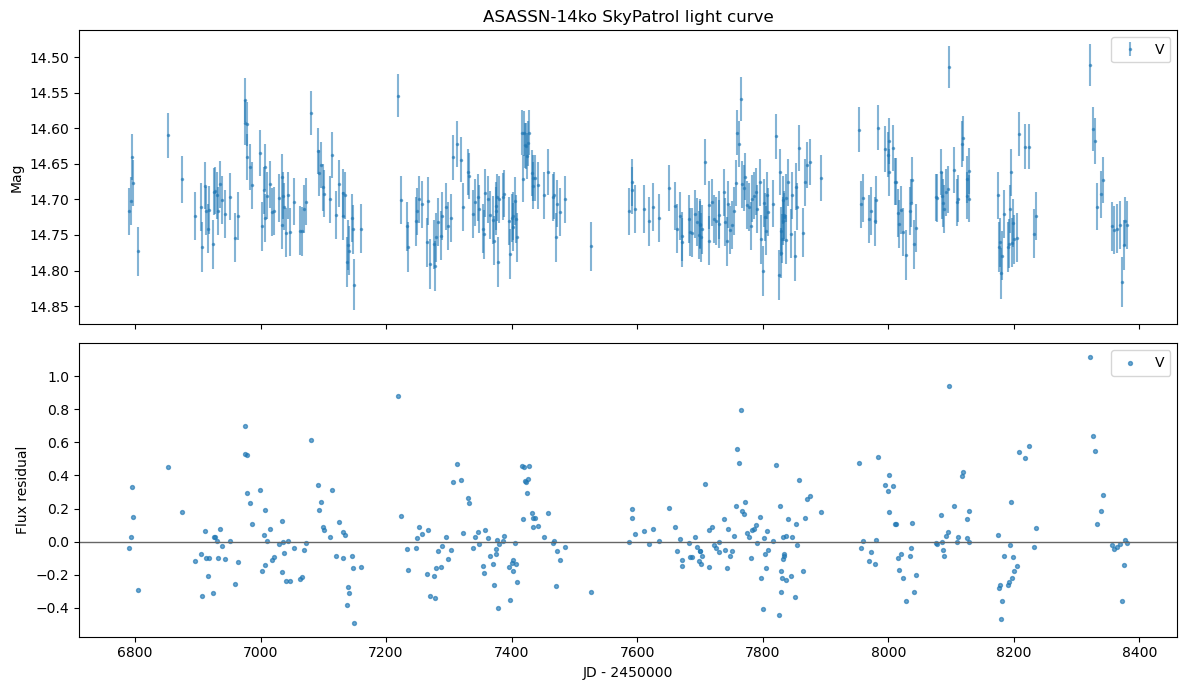

In [7]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
if not prepared_lc.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    for band, band_df in prepared_lc.groupby('band'):
        x = band_df['JD'] - 2450000.0
        axes[0].errorbar(x, band_df['mag'], yerr=band_df['error'], fmt='.', ms=3, alpha=0.55, label=band)
        axes[1].scatter(x, band_df['nuc_flux_resid'], s=8, alpha=0.65, label=band)
    axes[0].invert_yaxis()
    axes[0].set_ylabel('Mag')
    axes[0].set_title(f'{target_df.loc[0, "name"]} SkyPatrol light curve')
    axes[1].axhline(0, color='0.4', lw=1)
    axes[1].set_ylabel('Flux residual')
    axes[1].set_xlabel('JD - 2450000')
    axes[0].legend(loc='best')
    axes[1].legend(loc='best')
    finalize_publication_figure(fig)
    plt.show()
else:
    print('No prepared light curve to plot.')


## 7. Flare Detection

This cell thresholds bright positive residuals, groups nearby detections, merges g/V flare groups, and summarizes flare episodes.


In [8]:
def summarize_flare_points(points: pd.DataFrame, *, candidate_id: str, target_id: str, flare_id: int) -> dict[str, Any]:
    pts = points.sort_values('JD').copy()
    peak_idx = pts['nuc_flux_snr'].astype(float).idxmax()
    peak = pts.loc[peak_idx]
    jd = pts['JD'].astype(float).to_numpy()
    resid = pts['nuc_flux_resid'].astype(float).to_numpy()
    if len(jd) >= 2:
        fluence = float(np.trapz(np.maximum(resid, 0.0), jd))
    else:
        fluence = 0.0
    t_start = float(np.nanmin(jd))
    t_end = float(np.nanmax(jd))
    t_peak = float(peak['JD'])
    rise = t_peak - t_start
    decline = t_end - t_peak
    asymmetry = float(decline / rise) if rise > 0 else np.nan
    return {
        'candidate_id': candidate_id,
        'target_id': target_id,
        'flare_id': int(flare_id),
        'bands': ','.join(sorted(str(b) for b in pts['band'].dropna().unique())),
        't_start_jd': t_start,
        't_peak_jd': t_peak,
        't_centroid_jd': float(np.average(jd, weights=np.maximum(pts['nuc_flux_snr'].astype(float).to_numpy(), 0.0))) if np.nanmax(pts['nuc_flux_snr']) > 0 else t_peak,
        't_end_jd': t_end,
        'duration_days': float(t_end - t_start),
        'n_points': int(len(pts)),
        'n_nights': int(np.unique(np.floor(jd)).size),
        'n_cameras': int(pts['camera#'].dropna().astype(str).nunique()) if 'camera#' in pts.columns else 0,
        'peak_snr': float(peak['nuc_flux_snr']),
        'peak_flux_resid': float(peak['nuc_flux_resid']),
        'fluence_flux_days': fluence,
        'amp_flux_rel': float(np.nanmax(resid)),
        'width_days': float(t_end - t_start),
        'asymmetry': asymmetry,
        'flare_quality': 'ok',
    }


def split_flagged_groups(flagged: pd.DataFrame, *, max_gap_days: float) -> list[pd.DataFrame]:
    flagged = flagged.sort_values('JD').copy()
    groups = []
    current = []
    previous_jd = None
    for idx, row in flagged.iterrows():
        jd = float(row['JD'])
        if previous_jd is None or jd - previous_jd <= max_gap_days:
            current.append(idx)
        else:
            groups.append(flagged.loc[current].copy())
            current = [idx]
        previous_jd = jd
    if current:
        groups.append(flagged.loc[current].copy())
    return groups



def detect_band_flare_groups(flagged: pd.DataFrame, *, max_gap_days: float = MAX_FLARE_GAP_DAYS) -> list[pd.DataFrame]:
    """Group thresholded same-band flare points into contiguous candidate episodes."""
    return split_flagged_groups(flagged, max_gap_days=max_gap_days)


def detect_flares(
    prepared: pd.DataFrame,
    *,
    candidate_id: str,
    target_id: str,
    snr_threshold: float = FLARE_SNR_THRESHOLD,
    min_points: int = MIN_FLARE_POINTS,
    min_peak_snr: float = MIN_FLARE_PEAK_SNR,
    max_gap_days: float = MAX_FLARE_GAP_DAYS,
    max_duration_days: float = MAX_FLARE_DURATION_DAYS,
    merge_band_gap_days: float = MERGE_BAND_GAP_DAYS,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    if prepared.empty:
        return pd.DataFrame(), {'nuc_flare_status': 'empty_lc', 'nuc_n_flares': 0}
    provisional = []
    for band, band_df in prepared.groupby('band', sort=True):
        mask = (
            pd.to_numeric(band_df['nuc_flux_snr'], errors='coerce') >= float(snr_threshold)
        ) & (
            pd.to_numeric(band_df['nuc_flux_resid'], errors='coerce') > 0
        )
        flagged = band_df.loc[mask].copy()
        if flagged.empty:
            continue
        for group in detect_band_flare_groups(flagged, max_gap_days=max_gap_days):
            duration = float(group['JD'].max() - group['JD'].min())
            peak_snr = float(group['nuc_flux_snr'].max())
            if len(group) < int(min_points):
                continue
            if peak_snr < float(min_peak_snr):
                continue
            if duration > float(max_duration_days):
                continue
            provisional.append({
                'band': band,
                't_peak_jd': float(group.loc[group['nuc_flux_snr'].idxmax(), 'JD']),
                'points': group,
            })

    if not provisional:
        return pd.DataFrame(), {'nuc_flare_status': 'no_flares', 'nuc_n_flares': 0}

    provisional = sorted(provisional, key=lambda item: item['t_peak_jd'])
    merged: list[list[pd.DataFrame]] = []
    merged_peaks: list[float] = []
    for item in provisional:
        if merged and abs(float(item['t_peak_jd']) - merged_peaks[-1]) <= float(merge_band_gap_days):
            merged[-1].append(item['points'])
            all_pts = pd.concat(merged[-1], ignore_index=True)
            merged_peaks[-1] = float(all_pts.loc[all_pts['nuc_flux_snr'].idxmax(), 'JD'])
        else:
            merged.append([item['points']])
            merged_peaks.append(float(item['t_peak_jd']))

    rows = []
    for i, group_parts in enumerate(merged, start=1):
        points = pd.concat(group_parts, ignore_index=True)
        rows.append(summarize_flare_points(points, candidate_id=candidate_id, target_id=target_id, flare_id=i))
    flare_df = pd.DataFrame(rows).sort_values('t_peak_jd').reset_index(drop=True)
    summary = {
        'nuc_flare_status': 'ok',
        'nuc_n_flares': int(len(flare_df)),
        'nuc_peak_snr_max': float(flare_df['peak_snr'].max()) if not flare_df.empty else np.nan,
        'nuc_first_flare_jd': float(flare_df['t_peak_jd'].min()) if not flare_df.empty else np.nan,
        'nuc_last_flare_jd': float(flare_df['t_peak_jd'].max()) if not flare_df.empty else np.nan,
    }
    return flare_df, summary



def merge_multiband_flares(provisional: list[dict[str, Any]], *, candidate_id: str, target_id: str, merge_band_gap_days: float = MERGE_BAND_GAP_DAYS) -> pd.DataFrame:
    """Merge nearby g/V same-event flare groups into one flare table."""
    if not provisional:
        return pd.DataFrame()
    provisional = sorted(provisional, key=lambda item: item['t_peak_jd'])
    merged: list[list[pd.DataFrame]] = []
    merged_peaks: list[float] = []
    for item in provisional:
        if merged and abs(float(item['t_peak_jd']) - merged_peaks[-1]) <= float(merge_band_gap_days):
            merged[-1].append(item['points'])
            all_pts = pd.concat(merged[-1], ignore_index=True)
            merged_peaks[-1] = float(all_pts.loc[all_pts['nuc_flux_snr'].idxmax(), 'JD'])
        else:
            merged.append([item['points']])
            merged_peaks.append(float(item['t_peak_jd']))
    rows = []
    for i, group_parts in enumerate(merged, start=1):
        points = pd.concat(group_parts, ignore_index=True)
        rows.append(summarize_flare_points(points, candidate_id=candidate_id, target_id=target_id, flare_id=i))
    return pd.DataFrame(rows).sort_values('t_peak_jd').reset_index(drop=True)


candidate_id = str(target_df.loc[0, 'candidate_id'])
target_id = str(target_df.loc[0, 'target_id'])
flare_df, flare_summary = detect_flares(prepared_lc, candidate_id=candidate_id, target_id=target_id)
write_parquet_table(flare_df, nuclear_flares_path(RUN_DIR))
print('Flare summary:')
display(pd.DataFrame([flare_summary]))
display(flare_df)

Flare summary:


,nuc_flare_status,nuc_n_flares,nuc_peak_snr_max,nuc_first_flare_jd,nuc_last_flare_jd
0,ok,8,6.763636,2.456976e+06,2.458321e+06


,candidate_id,target_id,flare_id,bands,t_start_jd,t_peak_jd,t_centroid_jd,t_end_jd,duration_days,n_points,n_nights,n_cameras,peak_snr,peak_flux_resid,fluence_flux_days,amp_flux_rel,width_days,asymmetry,flare_quality
0,nuclear_asassn14ko,asassn14ko,1,V,2.456975e+06,2.456976e+06,2.456976e+06,2.456978e+06,3.07183,3,3,1,4.314815,0.6990,1.883688,0.6990,3.07183,1.853561,ok
1,nuclear_asassn14ko,asassn14ko,2,V,2.457081e+06,2.457081e+06,2.457081e+06,2.457081e+06,0.00000,1,1,1,3.829193,0.6165,0.000000,0.6165,0.00000,NaN,ok
2,nuclear_asassn14ko,asassn14ko,3,V,2.457219e+06,2.457219e+06,2.457219e+06,2.457219e+06,0.00000,1,1,1,5.386503,0.8780,0.000000,0.8780,0.00000,NaN,ok
3,nuclear_asassn14ko,asassn14ko,4,V,2.457760e+06,2.457765e+06,2.457763e+06,2.457765e+06,5.12923,2,2,1,4.907407,0.7950,3.475053,0.7950,5.12923,0.000000,ok
4,nuclear_asassn14ko,asassn14ko,5,V,2.457984e+06,2.457984e+06,2.457984e+06,2.457984e+06,0.00000,1,1,1,3.212500,0.5140,0.000000,0.5140,0.00000,NaN,ok
5,nuclear_asassn14ko,asassn14ko,6,V,2.458097e+06,2.458097e+06,2.458097e+06,2.458097e+06,0.00000,1,1,1,5.709091,0.9420,0.000000,0.9420,0.00000,NaN,ok
6,nuclear_asassn14ko,asassn14ko,7,V,2.458208e+06,2.458224e+06,2.458216e+06,2.458224e+06,15.95959,3,3,1,3.616352,0.5750,8.480706,0.5750,15.95959,0.000000,ok
7,nuclear_asassn14ko,asassn14ko,8,V,2.458321e+06,2.458321e+06,2.458325e+06,2.458330e+06,8.97634,3,3,1,6.763636,1.1160,6.723470,1.1160,8.97634,NaN,ok


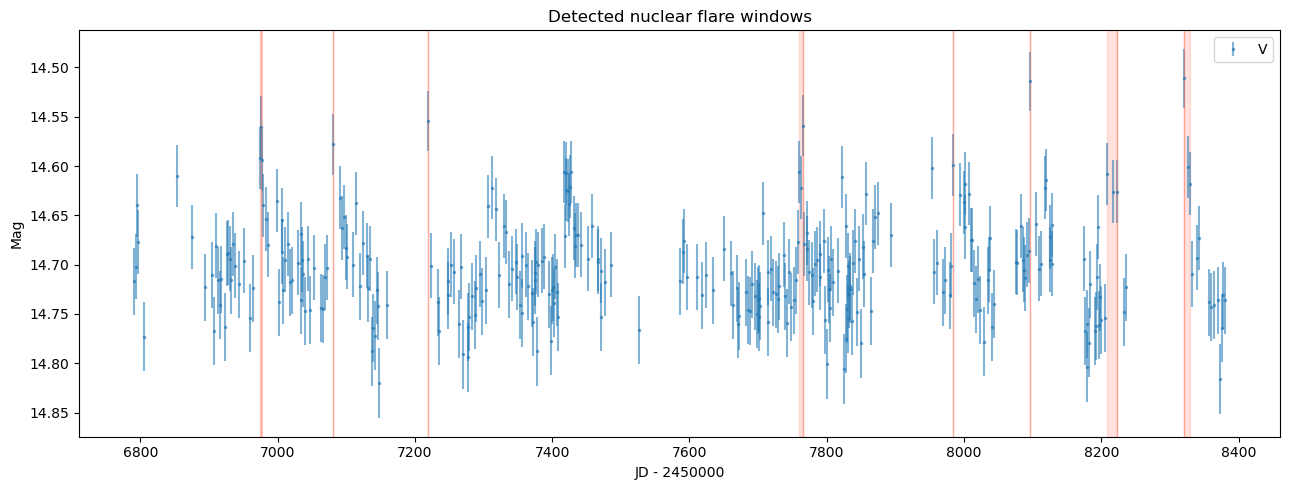

In [9]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
if not prepared_lc.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    for band, band_df in prepared_lc.groupby('band'):
        ax.errorbar(band_df['JD'] - 2450000.0, band_df['mag'], yerr=band_df['error'], fmt='.', ms=3, alpha=0.55, label=band)
    for _, flare in flare_df.iterrows():
        ax.axvspan(flare['t_start_jd'] - 2450000.0, flare['t_end_jd'] - 2450000.0, color='tomato', alpha=0.18)
        ax.axvline(flare['t_peak_jd'] - 2450000.0, color='tomato', alpha=0.45, lw=1)
    ax.invert_yaxis()
    ax.set_xlabel('JD - 2450000')
    ax.set_ylabel('Mag')
    ax.set_title('Detected nuclear flare windows')
    ax.legend(loc='best')
    finalize_publication_figure(fig)
    plt.show()
else:
    print('No prepared light curve to plot.')


## 8. Repeating Period Search

This is the inline event-time recurrence scorer. It searches trial periods from 30 to 1000 days, compares flare peak times to a linear ephemeris, penalizes missed observable cycles, and downweights seasonal aliases.

In [10]:
ALIAS_PERIODS_DAYS = (365.25, 365.25 / 2.0, 365.25 / 3.0, 365.25 / 4.0)


def coefficient_consistency(values: Iterable[float]) -> float:
    arr = np.asarray(list(values), dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return 1.0 if arr.size == 1 else np.nan
    med = float(np.median(np.abs(arr)))
    if med <= 0:
        return 1.0
    cv = float(np.nanstd(arr) / med)
    return float(1.0 / (1.0 + max(cv, 0.0)))


def alias_penalty_for_period(period: float) -> tuple[float, bool]:
    for alias in ALIAS_PERIODS_DAYS:
        if abs(float(period) - alias) <= 10.0:
            return 0.4, True
    return 0.0, False


def observable_predicted_peaks(observation_times: np.ndarray, *, t0: float, period: float, tolerance: float) -> np.ndarray:
    t_min = float(np.nanmin(observation_times))
    t_max = float(np.nanmax(observation_times))
    k_min = math.floor((t_min - t0) / period) - 1
    k_max = math.ceil((t_max - t0) / period) + 1
    peaks = t0 + np.arange(k_min, k_max + 1, dtype=float) * period
    peaks = peaks[(peaks >= t_min) & (peaks <= t_max)]
    if peaks.size == 0:
        return peaks
    observed = []
    obs = np.asarray(observation_times, dtype=float)
    for peak in peaks:
        observed.append(bool(np.any(np.abs(obs - peak) <= tolerance)))
    return peaks[np.asarray(observed, dtype=bool)]


def score_one_period(
    flare_table: pd.DataFrame,
    observation_times: np.ndarray,
    *,
    period: float,
    t0: float,
    min_matched_flares: int = MIN_REPEATING_FLARES,
) -> dict[str, Any]:
    flare_times = flare_table['t_peak_jd'].astype(float).to_numpy()
    if flare_times.size == 0:
        return {}
    tolerance = max(7.0, 0.08 * float(period))
    cycles = np.rint((flare_times - t0) / float(period)).astype(int)
    predicted = t0 + cycles * float(period)
    residuals = flare_times - predicted
    matched = np.abs(residuals) <= tolerance
    matched_count = int(matched.sum())
    matched_cycles = len(set(cycles[matched].tolist())) if matched_count else 0
    phase_rms = float(np.sqrt(np.mean(np.square(residuals[matched])))) if matched_count else np.inf
    observable = observable_predicted_peaks(observation_times, t0=t0, period=float(period), tolerance=tolerance)
    observable_count = int(len(observable))
    missed_count = max(0, observable_count - matched_cycles)

    phase_score = float(np.clip(1.0 - phase_rms / tolerance, 0.0, 1.0)) if np.isfinite(phase_rms) else 0.0
    coverage_score = float(matched_cycles / max(observable_count, matched_cycles, 1))
    count_score = float(np.clip((matched_count - 2.0) / 5.0, 0.0, 1.0))
    amp_score = coefficient_consistency(flare_table.loc[matched, 'peak_flux_resid']) if matched_count else 0.0
    width_score = coefficient_consistency(flare_table.loc[matched, 'duration_days']) if matched_count else 0.0
    morph_score = 0.5 * amp_score + 0.5 * width_score if np.isfinite(amp_score) and np.isfinite(width_score) else 0.0
    alias_penalty, alias_flag = alias_penalty_for_period(float(period))
    enough_matched = matched_count >= int(min_matched_flares) and matched_cycles >= int(min_matched_flares)
    raw_score = 0.40 * phase_score + 0.25 * coverage_score + 0.20 * count_score + 0.15 * morph_score
    final_score = 100.0 * raw_score * (1.0 - alias_penalty) if enough_matched else 0.0
    return {
        'period_days': float(period),
        't0_jd': float(t0),
        'matched_flares': matched_count,
        'matched_cycles': int(matched_cycles),
        'observable_cycles': observable_count,
        'missed_cycles': int(missed_count),
        'phase_rms_days': phase_rms,
        'phase_tolerance_days': float(tolerance),
        'phase_score': phase_score,
        'coverage_score': coverage_score,
        'count_score': count_score,
        'amp_consistency': float(amp_score),
        'width_consistency': float(width_score),
        'alias_flag': bool(alias_flag),
        'alias_penalty': float(alias_penalty),
        'enough_matched_flares': bool(enough_matched),
        'nuc_repeating_score': float(final_score),
    }


def score_repeating_flares(
    flare_table: pd.DataFrame,
    prepared: pd.DataFrame,
    *,
    min_period_days: float = PERIOD_MIN_DAYS,
    max_period_days: float = PERIOD_MAX_DAYS,
    min_repeating_flares: int = MIN_REPEATING_FLARES,
    grid_size: int = PERIOD_GRID_SIZE,
) -> tuple[dict[str, Any], pd.DataFrame]:
    default = {
        'nuc_n_flares': int(len(flare_table)),
        'nuc_best_period_days': np.nan,
        'nuc_period_score': 0.0,
        'nuc_repeating_score': 0.0,
        'nuc_phase_rms_days': np.nan,
        'nuc_phase_tolerance_days': np.nan,
        'nuc_matched_flare_count': 0,
        'nuc_matched_cycle_count': 0,
        'nuc_observable_cycle_count': 0,
        'nuc_missed_cycle_count': 0,
        'nuc_observed_cycle_fraction': 0.0,
        'nuc_amp_consistency': np.nan,
        'nuc_width_consistency': np.nan,
        'nuc_alias_flag': False,
        'nuc_repeating_candidate': False,
        'nuc_repeating_status': 'too_few_flares',
    }
    if flare_table.empty or len(flare_table) < int(min_repeating_flares):
        return default, pd.DataFrame()
    obs = prepared['JD'].astype(float).to_numpy()
    obs = obs[np.isfinite(obs)]
    if obs.size < 2:
        default['nuc_repeating_status'] = 'no_observation_times'
        return default, pd.DataFrame()
    time_span = float(np.nanmax(obs) - np.nanmin(obs))
    effective_max = min(float(max_period_days), 0.75 * time_span)
    if effective_max <= float(min_period_days):
        default['nuc_repeating_status'] = 'baseline_too_short'
        return default, pd.DataFrame()

    periods = np.linspace(float(min_period_days), effective_max, int(grid_size))
    flare_times = flare_table['t_peak_jd'].astype(float).to_numpy()
    scores = []
    for period in periods:
        best_for_period = None
        for t0 in flare_times:
            score = score_one_period(
                flare_table,
                obs,
                period=float(period),
                t0=float(t0),
                min_matched_flares=int(min_repeating_flares),
            )
            if best_for_period is None or score['nuc_repeating_score'] > best_for_period['nuc_repeating_score']:
                best_for_period = score
        if best_for_period is not None:
            scores.append(best_for_period)
    score_df = pd.DataFrame(scores)
    if score_df.empty:
        default['nuc_repeating_status'] = 'no_scores'
        return default, score_df
    score_df = score_df.sort_values('nuc_repeating_score', ascending=False).reset_index(drop=True)
    best = score_df.iloc[0].to_dict()
    observed_fraction = float(best['matched_cycles'] / max(best['observable_cycles'], best['matched_cycles'], 1))
    is_candidate = (
        int(len(flare_table)) >= int(min_repeating_flares)
        and int(best['matched_flares']) >= int(min_repeating_flares)
        and int(best['matched_cycles']) >= int(min_repeating_flares)
        and float(best['nuc_repeating_score']) >= 55.0
        and float(best['phase_rms_days']) <= float(best['phase_tolerance_days'])
    )
    result = {
        'nuc_n_flares': int(len(flare_table)),
        'nuc_best_period_days': float(best['period_days']),
        'nuc_best_t0_jd': float(best['t0_jd']),
        'nuc_period_score': float(best['nuc_repeating_score']),
        'nuc_repeating_score': float(best['nuc_repeating_score']),
        'nuc_phase_rms_days': float(best['phase_rms_days']),
        'nuc_phase_tolerance_days': float(best['phase_tolerance_days']),
        'nuc_matched_flare_count': int(best['matched_flares']),
        'nuc_matched_cycle_count': int(best['matched_cycles']),
        'nuc_observable_cycle_count': int(best['observable_cycles']),
        'nuc_missed_cycle_count': int(best['missed_cycles']),
        'nuc_observed_cycle_fraction': observed_fraction,
        'nuc_amp_consistency': float(best['amp_consistency']),
        'nuc_width_consistency': float(best['width_consistency']),
        'nuc_alias_flag': bool(best['alias_flag']),
        'nuc_repeating_candidate': bool(is_candidate),
        'nuc_repeating_status': 'ok' if is_candidate else 'nonrepeating',
    }
    return result, score_df


recurrence_summary, period_score_df = score_repeating_flares(flare_df, prepared_lc)
print('Recurrence summary:')
display(pd.DataFrame([recurrence_summary]))
print('Top trial periods:')
display(period_score_df.head(15))

Recurrence summary:


,nuc_n_flares,nuc_best_period_days,nuc_best_t0_jd,nuc_period_score,nuc_repeating_score,nuc_phase_rms_days,nuc_phase_tolerance_days,nuc_matched_flare_count,nuc_matched_cycle_count,nuc_observable_cycle_count,nuc_missed_cycle_count,nuc_observed_cycle_fraction,nuc_amp_consistency,nuc_width_consistency,nuc_alias_flag,nuc_repeating_candidate,nuc_repeating_status
0,8,110.045011,2.458097e+06,63.169403,63.169403,2.655641,8.803601,5,5,13,8,0.384615,0.816023,1.0,False,True,ok


Top trial periods:


,period_days,t0_jd,matched_flares,matched_cycles,observable_cycles,missed_cycles,phase_rms_days,phase_tolerance_days,phase_score,coverage_score,count_score,amp_consistency,width_consistency,alias_flag,alias_penalty,enough_matched_flares,nuc_repeating_score
0,110.045011,2.458097e+06,5,5,13,8,2.655641,8.803601,0.698346,0.384615,0.6,0.816023,1.000000,False,0.0,True,63.169403
1,109.802451,2.458097e+06,5,5,13,8,2.738548,8.784196,0.688242,0.384615,0.6,0.816023,1.000000,False,0.0,True,62.765221
2,109.317329,2.457219e+06,4,4,12,8,1.635461,8.745386,0.812992,0.333333,0.4,0.836577,1.000000,False,0.0,True,62.627325
3,111.742936,2.458097e+06,5,5,12,7,2.206011,8.939435,0.753227,0.416667,0.6,0.794595,0.475714,False,0.0,True,62.073067
4,110.287572,2.458097e+06,5,5,13,8,2.905320,8.823006,0.670711,0.384615,0.6,0.816023,1.000000,False,0.0,True,62.063994
5,250.245061,2.456976e+06,4,4,6,2,5.312910,20.019605,0.734615,0.666667,0.4,0.820750,0.189066,False,0.0,True,61.624870
6,250.487622,2.456976e+06,4,4,6,2,5.323693,20.039010,0.734334,0.666667,0.4,0.820750,0.189066,False,0.0,True,61.613625
7,250.002501,2.456976e+06,4,4,6,2,5.417367,20.000200,0.729134,0.666667,0.4,0.820750,0.189066,False,0.0,True,61.405658
8,250.730183,2.456976e+06,4,4,6,2,5.449032,20.058415,0.728342,0.666667,0.4,0.820750,0.189066,False,0.0,True,61.373957
9,227.686922,2.457081e+06,4,4,7,3,4.390184,18.214954,0.758979,0.571429,0.4,0.850605,0.282428,False,0.0,True,61.142620


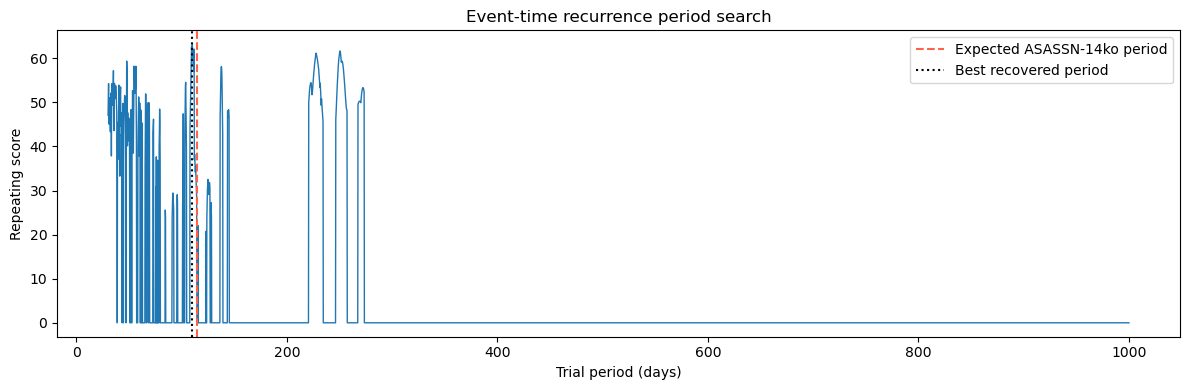

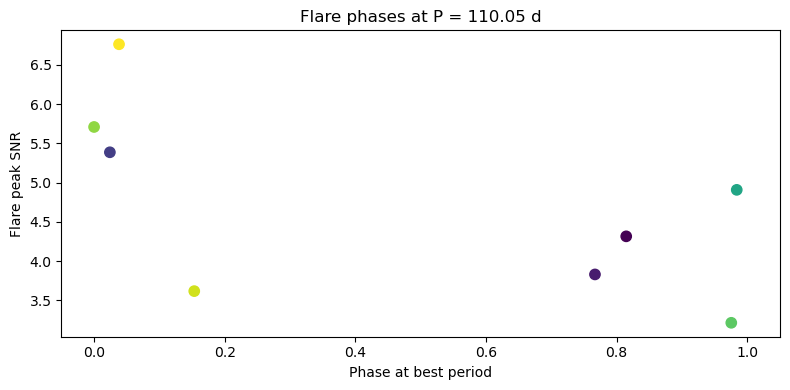

In [11]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_LC_WIDE,
    finalize_publication_figure,
)
if not period_score_df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(period_score_df.sort_values('period_days')['period_days'], period_score_df.sort_values('period_days')['nuc_repeating_score'], lw=1.0)
    ax.axvline(EXPECTED_PERIOD_DAYS, color='tomato', ls='--', label=f'Expected {target_df.loc[0, "name"]} period')
    ax.axvline(recurrence_summary['nuc_best_period_days'], color='black', ls=':', label='Best recovered period')
    ax.set_xlabel('Trial period (days)')
    ax.set_ylabel('Repeating score')
    ax.set_title('Event-time recurrence period search')
    ax.legend(loc='best')
    finalize_publication_figure(fig)
    plt.show()

    best_period = recurrence_summary['nuc_best_period_days']
    best_t0 = recurrence_summary.get('nuc_best_t0_jd', flare_df['t_peak_jd'].min() if not flare_df.empty else np.nan)
    if np.isfinite(best_period) and not flare_df.empty:
        phases = np.mod((flare_df['t_peak_jd'].astype(float) - best_t0) / best_period, 1.0)
        fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_LC_WIDE)
        ax.scatter(phases, flare_df['peak_snr'], s=55, c=flare_df['t_peak_jd'], cmap='viridis')
        ax.set_xlabel('Phase at best period')
        ax.set_ylabel('Flare peak SNR')
        ax.set_title(f'Flare phases at P = {best_period:.2f} d')
        ax.set_xlim(-0.05, 1.05)
        finalize_publication_figure(fig)
        plt.show()
else:
    print('No period-score grid to plot.')


## 9. Candidate Table And Review Mapping

This cell builds the candidate row and imports it into the existing review DB. Nuclear-specific fields are preserved in `payload_json` by the review DB importer, so the row is usable immediately from this notebook.


In [12]:
def truthy(value: object) -> bool:
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, (int, float, np.integer, np.floating)):
        return bool(value)
    return str(value).strip().lower() in {'1', 'true', 'yes', 'y', 't'}


def foreground_star_flag(row: dict[str, Any]) -> bool:
    parallax = numeric_or_nan(first_present(row, ('parallax', 'plx')))
    parallax_error = numeric_or_nan(first_present(row, ('parallax_error', 'plx_d')))
    pmra = numeric_or_nan(first_present(row, ('pmra', 'pm_ra')))
    pmdec = numeric_or_nan(first_present(row, ('pmdec', 'pm_dec')))
    pm_total = math.sqrt(pmra * pmra + pmdec * pmdec) if math.isfinite(pmra) and math.isfinite(pmdec) else np.nan
    parallax_snr = parallax / parallax_error if math.isfinite(parallax) and math.isfinite(parallax_error) and parallax_error > 0 else np.nan
    return bool((math.isfinite(parallax_snr) and parallax_snr >= 10.0) or (math.isfinite(pm_total) and pm_total >= 50.0))


def first_failure(row: dict[str, Any]) -> str:
    for key in (
        'nuc_failed_no_lc',
        'nuc_failed_low_quality_lc',
        'nuc_failed_no_flares',
        'nuc_failed_nonrepeating',
        'nuc_failed_foreground_star',
    ):
        if truthy(row.get(key)):
            return key.replace('nuc_failed_', '')
    return 'passed'


def classify_nuclear_candidate(row: dict[str, Any]) -> tuple[str, str, int]:
    if truthy(row.get('nuc_failed_no_lc')):
        return 'fetch_failed', 'no_usable_light_curve', 0
    if truthy(row.get('nuc_failed_foreground_star')):
        return 'foreground_contaminant', 'gaia_parallax_or_pm', 0
    if int(row.get('nuc_n_flares') or 0) <= 0:
        return 'no_flare', 'no_positive_flux_flare_groups', 0
    if truthy(row.get('nuc_repeating_candidate')):
        return 'repeating_nuclear_flare', 'phase_coherent_flare_train', 5
    score = float(row.get('nuc_repeating_score') or 0.0)
    if score >= 40.0 or int(row.get('nuc_n_flares') or 0) == 3:
        return 'possible_repeating_flare', 'moderate_recurrence_score', 4
    return 'nonrepeating_nuclear_flare', 'flare_groups_without_recurrence', 2


def build_candidate_table(
    manifest: pd.DataFrame,
    target_table: pd.DataFrame,
    phot_summary: dict[str, Any],
    flare_summary: dict[str, Any],
    recurrence_summary: dict[str, Any],
) -> pd.DataFrame:
    target = target_table.iloc[0].to_dict()
    fetched = manifest.iloc[0].to_dict() if not manifest.empty else {}
    row: dict[str, Any] = {
        'candidate_id': target['candidate_id'],
        'timescale': 'nuclear',
        'target_id': target['target_id'],
        'asas_sn_id': fetched.get('asas_sn_id', ''),
        'source_id': fetched.get('gaia_id', ''),
        'gaia_id': fetched.get('gaia_id', ''),
        'lc_path': fetched.get('lc_path', ''),
        'ra': target['ra'],
        'dec': target['dec'],
        'nuc_target_name': target.get('name', ''),
        'nuc_host_name': target.get('host_name', ''),
        'nuc_redshift': target.get('redshift', np.nan),
        'nuc_target_ra': target['ra'],
        'nuc_target_dec': target['dec'],
        'nuc_expected_period_days': target.get('expected_period_days', np.nan),
        'nuc_validation_mode': target.get('validation_mode', ''),
        'nuc_expected_min_flares': target.get('expected_min_flares', np.nan),
        'nuc_period_tolerance_days': target.get('period_tolerance_days', np.nan),
        'nuc_min_repeating_score': target.get('min_repeating_score', np.nan),
        'nuc_literature_note': target.get('literature_note', ''),
    }
    row.update(fetched)
    row.update(phot_summary)
    row.update(flare_summary)
    row.update(recurrence_summary)

    row['nuc_failed_no_lc'] = fetched.get('nuc_fetch_status') != 'fetched'
    row['nuc_failed_low_quality_lc'] = phot_summary.get('nuc_clean_status') != 'ok'
    row['nuc_failed_no_flares'] = int(row.get('nuc_n_flares') or 0) <= 0
    row['nuc_failed_nonrepeating'] = not truthy(row.get('nuc_repeating_candidate'))
    row['nuc_failed_foreground_star'] = foreground_star_flag(row)
    nuc_class, reason, score = classify_candidate(row)
    row['nuc_class'] = nuc_class
    row['nuc_class_reason'] = reason
    row['nuc_interest_score'] = score
    row['failed_any'] = bool(
        row['nuc_failed_no_lc']
        or row['nuc_failed_low_quality_lc']
        or row['nuc_failed_no_flares']
        or row['nuc_failed_nonrepeating']
        or row['nuc_failed_foreground_star']
    )
    row['filter_reason'] = first_failure(row)
    return pd.DataFrame([row])



def classify_candidate(row: dict[str, Any]) -> tuple[str, str, int]:
    """Candidate-classification wrapper kept inline for readability."""
    return classify_nuclear_candidate(row)


def build_candidate_row(
    manifest: pd.DataFrame,
    target_table: pd.DataFrame,
    phot_summary: dict[str, Any],
    flare_summary: dict[str, Any],
    recurrence_summary: dict[str, Any],
) -> dict[str, Any]:
    """Return the single review candidate row before table serialization."""
    return build_candidate_table(manifest, target_table, phot_summary, flare_summary, recurrence_summary).iloc[0].to_dict()


def ingest_inline_nuclear_candidates(review_db: Path, candidates: pd.DataFrame, *, source_path: Path, review_all: bool = REVIEW_ALL) -> tuple[int, int]:
    review_df = candidates.copy()
    if not review_all and 'failed_any' in review_df.columns:
        review_df = review_df.loc[~review_df['failed_any'].fillna(False).astype(bool)].copy()
    if review_df.empty:
        conn = db_connect(review_db)
        conn.close()
        print('No passing candidates to ingest. Use REVIEW_ALL=True to import failed/nonrepeating rows.')
        return 0, 0
    conn = db_connect(review_db)
    try:
        total, new = import_candidates(
            conn,
            review_df,
            source_path=str(source_path),
            characterize_before_import=False,
            vet_before_import=RUN_VETTING,
        )
    finally:
        conn.close()
    return total, new


candidate_df = build_candidate_table(lightcurve_manifest, target_df, phot_summary, flare_summary, recurrence_summary)
write_parquet_table(candidate_df, nuclear_candidates_path(RUN_DIR))
total_review_rows, new_review_rows = ingest_inline_nuclear_candidates(nuclear_review_db_path(RUN_DIR), candidate_df, source_path=RUN_DIR)

print('Candidate table:')
display(candidate_df)
print(f'Review ingest: {new_review_rows} new / {total_review_rows} total')

Candidate table:


,candidate_id,timescale,target_id,asas_sn_id,source_id,gaia_id,lc_path,ra,dec,nuc_target_name,nuc_host_name,nuc_redshift,nuc_target_ra,nuc_target_dec,nuc_expected_period_days,nuc_validation_mode,nuc_expected_min_flares,nuc_period_tolerance_days,nuc_min_repeating_score,nuc_literature_note,name,host_name,redshift,target_ra,target_dec,expected_period_days,nuc_fetch_backend,nuc_fetch_status,nuc_fetch_error,match_ra,match_dec,nuc_cone_sep_arcsec,nuc_cone_n_matches,nuc_fetch_attempts_json,nuc_fetch_backend_used,nuc_fetch_id_kind_used,nuc_fetch_id_used,dec_deg,epochs,gaia_b_mag,gaia_b_mag_d,gaia_eff_temp,gaia_g_extinc,gaia_mag,gaia_mag_d,gaia_r_mag,gaia_r_mag_d,gaia_var,mean_vmag,nstat,plx,plx_d,pm_dec,pm_dec_d,pm_ra,pm_ra_d,pstarrs_g_mag,pstarrs_g_mag_chi,pstarrs_g_mag_contrib,pstarrs_g_mag_d,pstarrs_i_mag,pstarrs_i_mag_chi,pstarrs_i_mag_contrib,pstarrs_i_mag_d,pstarrs_r_mag,pstarrs_r_mag_chi,pstarrs_r_mag_contrib,pstarrs_r_mag_d,pstarrs_z_mag,pstarrs_z_mag_chi,pstarrs_z_mag_contrib,pstarrs_z_mag_d,ra_deg,refcat_id,rp_00_1,rp_01,rp_10,sfd_g_extinc,sp1_link,sp1_sep_arcsec,sp1_source_catalog,sp1_source_id,tic_id,nuc_n_points_raw,nuc_n_points_clean,nuc_bad_cameras_filtered,nuc_clean_status,nuc_n_points_g,nuc_n_points_v,nuc_jd_first,nuc_jd_last,nuc_time_span_days,nuc_peak_snr_max,nuc_flare_status,nuc_n_flares,nuc_first_flare_jd,nuc_last_flare_jd,nuc_best_period_days,nuc_best_t0_jd,nuc_period_score,nuc_repeating_score,nuc_phase_rms_days,nuc_phase_tolerance_days,nuc_matched_flare_count,nuc_matched_cycle_count,nuc_observable_cycle_count,nuc_missed_cycle_count,nuc_observed_cycle_fraction,nuc_amp_consistency,nuc_width_consistency,nuc_alias_flag,nuc_repeating_candidate,nuc_repeating_status,nuc_failed_no_lc,nuc_failed_low_quality_lc,nuc_failed_no_flares,nuc_failed_nonrepeating,nuc_failed_foreground_star,nuc_class,nuc_class_reason,nuc_interest_score,failed_any,filter_reason
0,nuclear_asassn14ko,nuclear,asassn14ko,498216284073,4262829f-7832-5009-9bd9-5f44d0b40491,,/Users/calder/code/malca/output/runs/nuclear/a...,81.3255,-46.0057,ASASSN-14ko,ESO 253-G003,0.042489,81.3255,-46.0057,114.2,many_cycle,5,10.0,55.0,ASAS-SN optical periodic nuclear transient; ma...,ASASSN-14ko,ESO 253-G003,0.042489,81.3255,-46.0057,114.2,skypatrol2,fetched,,81.325528,-46.005605,0.348499,3,"[{""backend"": ""skypatrol2"", ""id_kind"": ""asas_sn...",skypatrol2,asas_sn_id,498216284073,-46.00566,301,16.033001,0.029,5095,0.0,16.43,0.006,15.238,0.018,2,14.7,3,-0.8,0.14,-1.85,0.31,-0.05,0.33,15.193,3.03,112,0.019,14.489,8.61,112,0.028,14.73,9.05,112,0.028,15.418,10.29,1,0.092,81.3254,52790813255273484,33.700001,99.900002,99.900002,0.136,https://asas-sn.osu.edu/photometry/4262829f-78...,0.375929,DR9,4262829f-7832-5009-9bd9-5f44d0b40491,734783930,309,309,,ok,0,309,2.456790e+06,2.458381e+06,1590.30011,6.763636,ok,8,2.456976e+06,2.458321e+06,110.045011,2.458097e+06,63.169403,63.169403,2.655641,8.803601,5,5,13,8,0.384615,0.816023,1.0,False,True,ok,False,False,False,False,False,repeating_nuclear_flare,phase_coherent_flare_train,5,False,passed


Review ingest: 1 new / 1 total


## 10. Acceptance Check

These checks intentionally fail loudly when the selected target is not recovered. ASASSN-14ko uses the many-cycle acceptance rule; the literature sparse-repeat presets use a two-flare rule with target-specific period and score tolerances.


In [13]:
def review_db_contains_candidate(db_path: Path, candidate_id: str) -> bool:
    if not db_path.exists():
        return False
    with sqlite3.connect(db_path) as conn:
        row = conn.execute('SELECT COUNT(*) FROM candidates WHERE candidate_id=?', (candidate_id,)).fetchone()
    return bool(row and int(row[0]) > 0)


def write_run_summary(run_dir: Path, summary: dict[str, Any]) -> Path:
    """Write the notebook run summary artifact."""
    path = run_dir / 'run_summary.json'
    write_json(path, summary)
    return path


def finite_or_nan(value: object) -> float:
    try:
        out = float(value)
    except Exception:
        return float('nan')
    return out if math.isfinite(out) else float('nan')


row = candidate_df.iloc[0]
expected_period = finite_or_nan(EXPECTED_PERIOD_DAYS)
best_period = finite_or_nan(row.get('nuc_best_period_days'))
period_error = best_period - expected_period if math.isfinite(best_period) and math.isfinite(expected_period) else np.nan
candidate_id = str(row['candidate_id'])

acceptance = {
    'target_id': TARGET_ID,
    'validation_mode': VALIDATION_MODE,
    'fetch_status_fetched': row.get('nuc_fetch_status') == 'fetched',
    'min_expected_flares': int(row.get('nuc_n_flares') or 0) >= int(EXPECTED_MIN_FLARES),
    'is_repeating_candidate': bool(row.get('nuc_repeating_candidate')) is True,
    'period_within_tolerance': bool(math.isfinite(period_error) and abs(period_error) <= float(EXPECTED_PERIOD_TOLERANCE_DAYS)),
    'score_at_least_minimum': float(row.get('nuc_repeating_score') or 0.0) >= float(EXPECTED_MIN_REPEATING_SCORE),
    'review_db_contains_candidate': review_db_contains_candidate(nuclear_review_db_path(RUN_DIR), candidate_id),
}
acceptance_df = pd.DataFrame([acceptance])
display(acceptance_df)

assert acceptance['fetch_status_fetched'], f"Expected fetched light curve, got {row.get('nuc_fetch_status')!r}: {row.get('nuc_fetch_error', '')}"
assert acceptance['min_expected_flares'], f"Expected at least {EXPECTED_MIN_FLARES} flares for {TARGET_ID}, got {row.get('nuc_n_flares')}"
assert acceptance['is_repeating_candidate'], 'Expected nuc_repeating_candidate=True'
assert acceptance['period_within_tolerance'], (
    f"Expected period within {EXPECTED_PERIOD_TOLERANCE_DAYS:g} d of {expected_period:g}, "
    f"got {row.get('nuc_best_period_days')}"
)
assert acceptance['score_at_least_minimum'], (
    f"Expected repeating score >= {EXPECTED_MIN_REPEATING_SCORE:g}, got {row.get('nuc_repeating_score')}"
)
assert acceptance['review_db_contains_candidate'], f'Expected review DB to contain {candidate_id}'

summary = {
    'timestamp': pd.Timestamp.utcnow().isoformat(),
    'target_id': TARGET_ID,
    'target_name': str(target_df.loc[0, 'name']),
    'validation_mode': VALIDATION_MODE,
    'candidate_id': candidate_id,
    'nuc_fetch_status': row.get('nuc_fetch_status'),
    'nuc_n_flares': int(row.get('nuc_n_flares') or 0),
    'nuc_best_period_days': best_period,
    'expected_period_days': expected_period,
    'period_error_days': period_error,
    'period_tolerance_days': float(EXPECTED_PERIOD_TOLERANCE_DAYS),
    'nuc_repeating_score': float(row.get('nuc_repeating_score') or 0.0),
    'expected_min_repeating_score': float(EXPECTED_MIN_REPEATING_SCORE),
    'review_db': str(nuclear_review_db_path(RUN_DIR)),
    'acceptance': acceptance,
}
write_run_summary(RUN_DIR, summary)
print(f'{target_df.loc[0, "name"]} recovery acceptance passed ({VALIDATION_MODE}).')
print(json.dumps(summary, indent=2, default=str))


,target_id,validation_mode,fetch_status_fetched,min_expected_flares,is_repeating_candidate,period_within_tolerance,score_at_least_minimum,review_db_contains_candidate
0,asassn14ko,many_cycle,True,True,True,True,True,True


ASASSN-14ko recovery acceptance passed (many_cycle).
{
  "timestamp": "2026-06-03T05:03:57.181676+00:00",
  "target_id": "asassn14ko",
  "target_name": "ASASSN-14ko",
  "validation_mode": "many_cycle",
  "candidate_id": "nuclear_asassn14ko",
  "nuc_fetch_status": "fetched",
  "nuc_n_flares": 8,
  "nuc_best_period_days": 110.0450112528132,
  "expected_period_days": 114.2,
  "period_error_days": -4.154988747186806,
  "period_tolerance_days": 10.0,
  "nuc_repeating_score": 63.16940328957039,
  "expected_min_repeating_score": 55.0,
  "review_db": "/Users/calder/code/malca/output/runs/nuclear/asassn14ko_notebook/review/review.db",
  "acceptance": {
    "target_id": "asassn14ko",
    "validation_mode": "many_cycle",
    "fetch_status_fetched": true,
    "min_expected_flares": true,
    "is_repeating_candidate": true,
    "period_within_tolerance": true,
    "score_at_least_minimum": true,
    "review_db_contains_candidate": true
  }
}


## 11. Notebook Section Map

The notebook stages are kept inline and ordered top-to-bottom:

```text
target selection and validation mode
coordinate fetch
photometry prep
flare grouping
recurrence scoring
review ingest
run summary and acceptance checks
```

Use `TARGET_ID = 'asassn14ko'` for the many-cycle benchmark. Use `TARGET_ID = 'at2020vdq'`, `TARGET_ID = 'at2022dbl'`, or `TARGET_ID = 'at2018fyk'` for sparse two-flare literature tests.
